<a href="https://colab.research.google.com/github/Annette-1/SIMULACION-II/blob/main/Matrices_elevadas_CM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:orange;"> Comportamiento a largo plazo de Cadenas de Markov</span>

Dada la matriz de probabiliddaes de transición $P$ y el estado inicial $\pi_0$ de una cadena de Markov, la distribución del tiempo siguiente se calculo como:
 $$\pi_0 =\pi_1 P
$$

In [141]:
from sympy import Matrix, init_printing, symbols, Eq, solve, eye
import numpy as np
import matplotlib.pyplot as plt

init_printing(use_unicode=True)

In [142]:
P=Matrix([[0.6,0.4],[0.2,0.8]])

In [143]:
P

⎡0.6  0.4⎤
⎢        ⎥
⎣0.2  0.8⎦

Distribución inicial

$\pi_0= [1,0]$

In [144]:
p=Matrix([[1,0]])

In [145]:
p

[1  0]

Calculamos el vector para el tiempo $1$

In [146]:
p0=p*P
p0

[0.6  0.4]

Probalidad del que el sábado llueva, lo cual corresponde a resolver la ecuación
$$
\pi_5= \pi_0 * P^5
$$

In [147]:
p5= p*P**5

In [148]:
p5

[0.34016  0.65984]

¿Cuál es la probabilidad de que a largo plazo un día sea soleado? Acompañe su respuesta de una gráfica.

Para ello definimos la **DISTRIBUCIÓN ESTACIONARIA** (LARGO PLAZO)

Resolviendo el sistema:
$$π = π · P \quad  (punto \quad fijo)  $$  
Se debe cumplir que:
$$suma(π) = 1$$
 Esto  es e quivalente a resolver  $π (P - I) = 0$  con  $π1 + π2 = 1$

In [149]:
x, y = symbols('x y') #trabajar con simbolos

# Ecuaciones: π·P = π  y  x + y = 1
ec1 = Eq(x*0.6 + y*0.2, x)   # primera componente de π·P = π
ec2 = Eq(x + y, 1)           # normalización

sol = solve((ec1, ec2), (x, y))

In [150]:
print("\nDistribución estacionaria π*:")
print(f"  Soleado  : {float(sol[x]):.4f}")
print(f"  Lluvioso : {float(sol[y]):.4f}")


Distribución estacionaria π*:
  Soleado  : 0.3333
  Lluvioso : 0.6667


 Verificamos si se cimple  $π^* · P = π^*$

In [151]:
pi_est = Matrix([[sol[x], sol[y]]])
display(pi_est * P)

[0.333333333333333  0.666666666666667]

Entonces la distribución estacionaria a largo plazo es $π^* = [\frac{1}{3}, \frac{2}{3}]$

A continuación mostramos la  Gráfica de la convergencia para ello calculamos
 $π_t = π0 · P^t$ para $t = 0,1,...,20$ y se grafica la probabilidad de cada estado.

In [152]:
n_steps = 20 #podemos modificar este parametro n
prob_sol = []   # P(Soleado) en cada instante
prob_llu = []   # P(Lluvioso) en cada instante

In [153]:
#creamos un ciclo
for t in range(n_steps + 1):
    pi_t = p0 * (P**t)
    prob_sol.append(float(pi_t[0]))
    prob_llu.append(float(pi_t[1]))

tiempo = list(range(n_steps + 1)) #lista para los tiempos

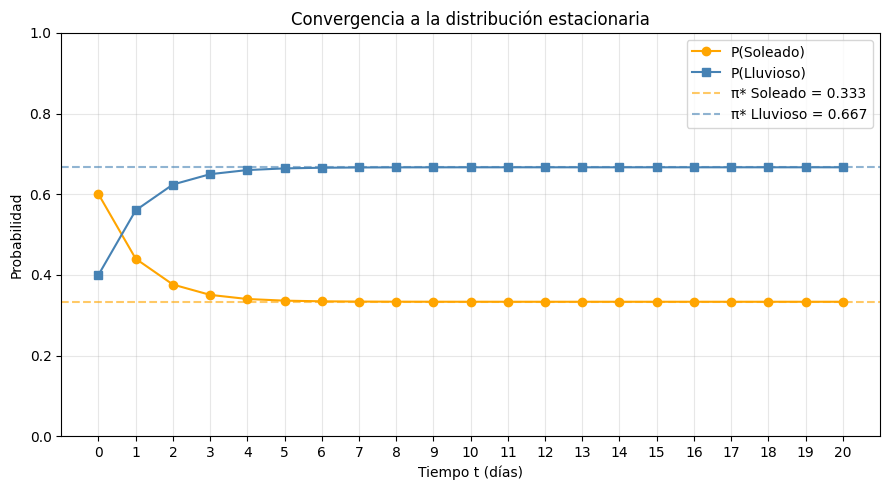

In [154]:
plt.figure(figsize=(9, 5))
plt.plot(tiempo, prob_sol, 'o-', color='orange', label='P(Soleado)')
plt.plot(tiempo, prob_llu, 's-', color='steelblue', label='P(Lluvioso)')

# Línea horizontal: valor estacionario de "Soleado"
plt.axhline(float(sol[x]), color='orange', linestyle='--', alpha=0.6,
            label=f'π* Soleado = {float(sol[x]):.3f}')
plt.axhline(float(sol[y]), color='steelblue', linestyle='--', alpha=0.6,
            label=f'π* Lluvioso = {float(sol[y]):.3f}')

plt.title('Convergencia a la distribución estacionaria')
plt.xlabel('Tiempo t (días)')
plt.ylabel('Probabilidad')
plt.xticks(tiempo)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Cadenas de Markov: Ejemplo**

Tenemos la siguiente matrix de transición

$$P=
\begin{bmatrix}
0.80 & 0.15 & 0.05 \\
0.06 & 0.90 & 0.04 \\
0.04 & 0.06 & 0.90
\end{bmatrix}
$$

Dada una matriz de transición $P$ (3 estados) y una distribución inicial $π_0$, se estudia:
 1) La evolución temporal de la cadena.
 2) La distribución en el tiempo $t$.
 3) La distribución estacionaria (largo plazo).
 4) Gráfica de convergencia hacia el estado estacionario.

In [155]:
from sympy import Matrix, init_printing, symbols, Eq, solve
import matplotlib.pyplot as plt

init_printing(use_unicode=True)

In [156]:
#P1[i, j] = probabilidad de pasar del estado i al estado j
# Cada fila debe sumar 1 (matriz estocástica por filas).
# ------------------------------------------------------------
P1 = Matrix([
    [0.80, 0.15, 0.05],
    [0.06, 0.90, 0.04],
    [0.04, 0.06, 0.90]
])

In [157]:
P1 #Matriz de transición

⎡0.8   0.15  0.05⎤
⎢                ⎥
⎢0.06  0.9   0.04⎥
⎢                ⎥
⎣0.04  0.06  0.9 ⎦

Verificamos que cada fila suma 1

In [158]:
for i in range(P1.rows):
    print(f"  Fila {i+1}: {sum(P1[i, :])}") #suma de filas

  Fila 1: 1.00000000000000
  Fila 2: 1.00000000000000
  Fila 3: 1.00000000000000


DISTRIBUCIÓN INICIAL

Suponemos que comenzamos seguros en el Estado 1:
$$π0 = [1, 0, 0]$$
Podemos proponer cualquier vector inicial

In [159]:
pi0 = Matrix([[0, 1, 0]])
print("\nDistribución inicial π0:")
display(pi0)


Distribución inicial π0:


[0  1  0]

DISTRIBUCIÓN EN $t = 1$

In [160]:
# π1 = π0 · P
pi1 = pi0 * P1
pi1

[0.06  0.9  0.04]

DISTRIBUCIÓN EN $t = 5$

In [161]:
# π5 = π0 · P^5
pi5 = pi0 * P1**5
pi5


[0.1742116216  0.670592436  0.1551959424]

 DISTRIBUCIÓN ESTACIONARIA (LARGO PLAZO)

Resolvemos el sistema:

$ π = π · P  $      (punto fijo)

Condición de normalización $π1 + π2 + π3 = 1$

In [162]:
x, y, z = symbols('x y z')

# Componentes de π·P = π
ec1 = Eq(x*0.80 + y*0.06 + z*0.04, x)
ec2 = Eq(x*0.15 + y*0.90 + z*0.06, y)
# La tercera ecuación es redundante (fila dependiente), usamos normalización
ec3 = Eq(x + y + z, 1)

In [163]:
sol = solve((ec1, ec2, ec3), (x, y, z))
print("\nDistribución estacionaria π*:")
print(f"  Estado 1 : {float(sol[x]):.4f}")
print(f"  Estado 2 : {float(sol[y]):.4f}")
print(f"  Estado 3 : {float(sol[z]):.4f}")


Distribución estacionaria π*:
  Estado 1 : 0.2077
  Estado 2 : 0.4918
  Estado 3 : 0.3005


Verificamos que se cumpla $π^* · P = π^*$

In [164]:
pi_est = Matrix([[sol[x], sol[y], sol[z]]])
display(pi_est * P1)

[0.207650273224044  0.491803278688525  0.300546448087432]

Graficamos para ver como converge a la distribución estacionaria

In [165]:
n_steps = 20
prob_1, prob_2, prob_3 = [], [], []

In [166]:
for t in range(n_steps + 1):
    pi_t = pi0 * (P1**t)
    prob_1.append(float(pi_t[0]))
    prob_2.append(float(pi_t[1]))
    prob_3.append(float(pi_t[2]))

tiempo = list(range(n_steps + 1))

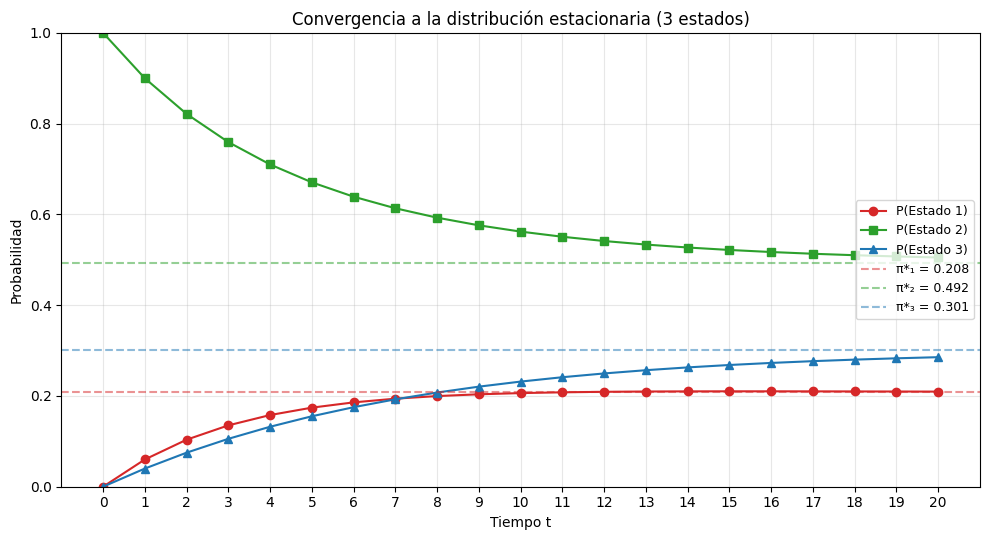

In [167]:
plt.figure(figsize=(10, 5.5))
plt.plot(tiempo, prob_1, 'o-', color='tab:red',    label='P(Estado 1)')
plt.plot(tiempo, prob_2, 's-', color='tab:green',  label='P(Estado 2)')
plt.plot(tiempo, prob_3, '^-', color='tab:blue',   label='P(Estado 3)')
# Líneas horizontales: valores estacionarios
plt.axhline(float(sol[x]), color='tab:red',   linestyle='--', alpha=0.5,
            label=f'π*₁ = {float(sol[x]):.3f}')
plt.axhline(float(sol[y]), color='tab:green', linestyle='--', alpha=0.5,
            label=f'π*₂ = {float(sol[y]):.3f}')
plt.axhline(float(sol[z]), color='tab:blue',  linestyle='--', alpha=0.5,
            label=f'π*₃ = {float(sol[z]):.3f}')

plt.title('Convergencia a la distribución estacionaria (3 estados)')
plt.xlabel('Tiempo t')
plt.ylabel('Probabilidad')
plt.xticks(tiempo)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(loc='center right', fontsize=9)
plt.tight_layout()
plt.show()


* En $t = 0$ la cadena está segura en el Estado 1 (probabilidad $1$).

* Al inicio, $P$(Estado 1) cae rápidamente mientras $P$(Estado 2) y P(Estado 3) crecen.

* A partir de aproximadamente $t = 8$ o $t = 10$, las tres curvas se estabilizan sobre sus valores estacionarios (líneas discontinuas).

* El comportamiento se debe a que la matriz $P$ tiene todos los elementos positivos, por lo que la cadena es irreducible y aperiódica, garantizando convergencia única independientemente del estado inicial.